In [1]:
# read in data
import pandas as pd

# training dataset 
df = pd.read_csv('../../SAC105_Data/data.csv')

# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')

# ISO surface 

In [2]:
# use isosurface method

from BgoKit import ToolKit
import Bgolearn.BGOsampling as BGOS
Bgolearn = BGOS.Bgolearn() 


Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.UCB()  

Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.UCB()


BgoKit, A tool package for Bgolearn
If you need any help, please contact me at github.com/Bin-Cao/Bgolearn
Executed on : 2024-12-15 17:32:37  | Have a great day.
 __  __         _  _    _          ___   _        _      
|  \/  | _   _ | || |_ (_)        / _ \ | |__    (_) ___ 
| |\/| || | | || || __|| | _____ | | | || '_ \   | |/ __|
| |  | || |_| || || |_ | ||_____|| |_| || |_) |  | |\__ \
|_|  |_| \__,_||_| \__||_|        \___/ |_.__/  _/ ||___/
                                               |__/      

MultiBgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/MultiBgolearn
Doc : https://bgolearn.netlify.app/
Executed on : 2024-12-15 17:32:37  | Have a great day.
 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, 

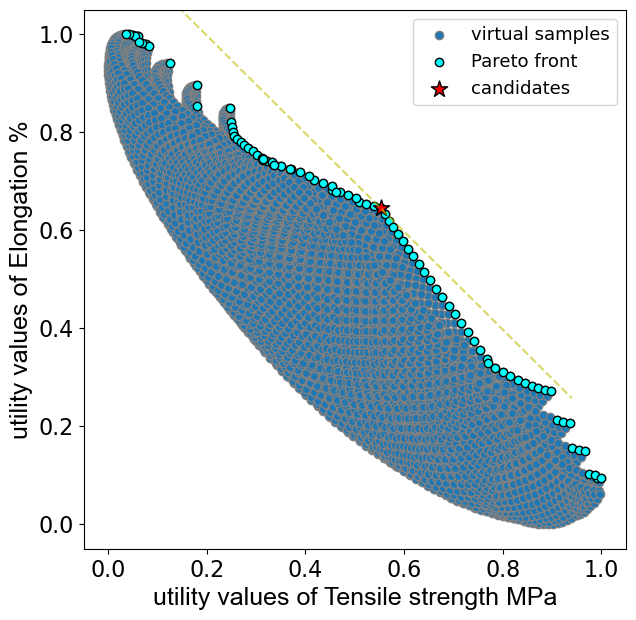

The optimal condidate recommended by BgoKit is : [[94.2  2.1  1.5  0.7]]


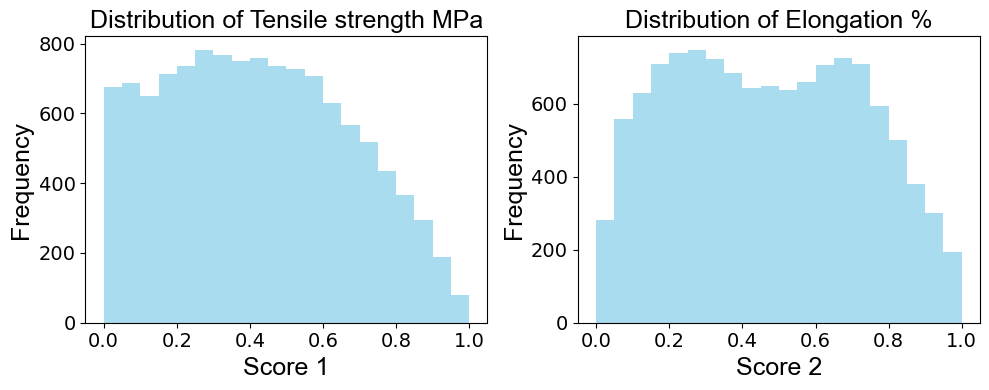

In [3]:
names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
Model.BiSearch()
Model.plot_distribution()

# UCB+HV selection

Pay attention: This is only available for the UCB method!



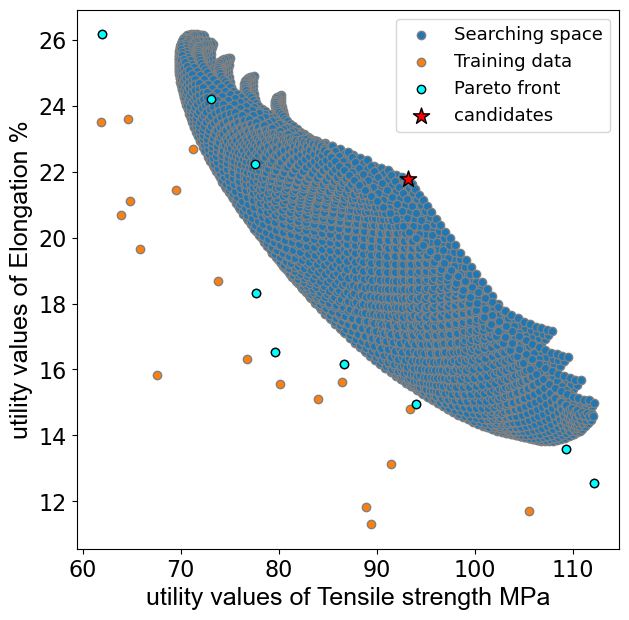

The next recommended data by method EV is: [90.8  1.5  5.5  0.7]
The hypervolume improvement is: 94.78347287273581


In [3]:
# Based on the UCB strategy, we selected the point with the largest hypervolume improvement compared to the rescaled training dataset's Pareto front

names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx = Model.HVSearch(y = df.iloc[:,-2:])



### 1st

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-15 17:07:24  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [86.8  5.5  5.5  0.7]
The predictions of Bgolearn are : 
 y =  105.92039764709571
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [95.   1.5  1.8  0.2]
The predictions of Bg

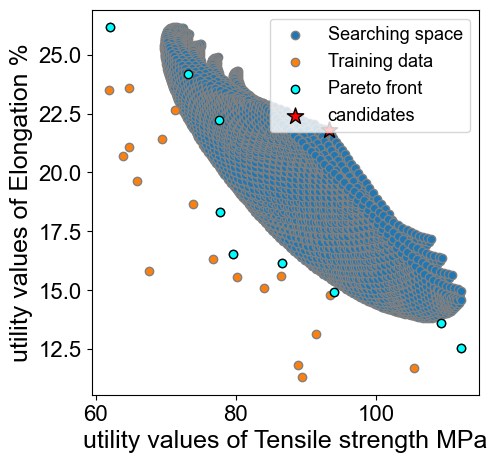

The next recommended data by method EV is: [93.21356512373043, 21.78388276505399]
The hypervolume improvement is: 94.78347287273581
the recommended data is : [90.8  1.5  5.5  0.7]
the HV is : 94.78347287273581
Predicted value for target 1: 83.38449521202325
Predicted value for target 2: 18.626684802883755


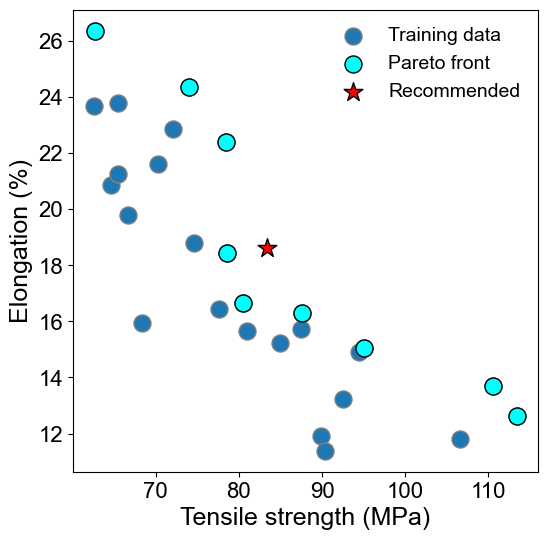

In [14]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = '../../SAC105_Data/data.csv'

# UCB+HV selection
#################################################
import Bgolearn.BGOsampling as BGOS

df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')
Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.UCB()  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.UCB()

names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx, HV_improve = Model.HVSearch(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
print('the HV is :', HV_improve[best_idx])
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_1.png', dpi=800)
plt.savefig('ParetoF_1.svg', dpi=800)
plt.show()
#################################################

In [15]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./new_datasets/first.csv', index=False)

### 2nd

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-12-15 17:07:29  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [86.8  5.5  5.5  0.7]
The predictions of Bgolearn are : 
 y =  105.87321254513989
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [95.   1.5  1.8  0.2]
The predictions of Bg

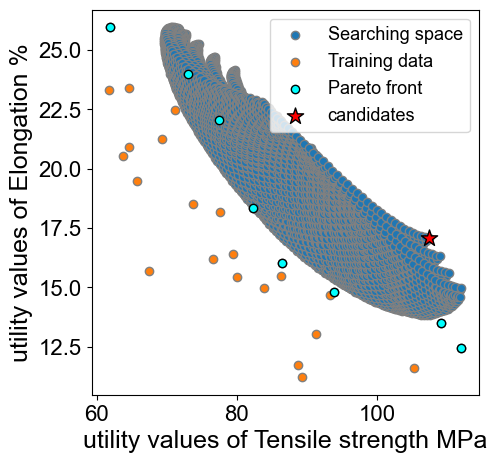

The next recommended data by method EV is: [107.35229305532579, 17.08519289648277]
The hypervolume improvement is: 69.64788653586248
the recommended data is : [87.4  5.5  5.5  0.1]
the HV is : 69.64788653586248
Predicted value for target 1: 110.27617548266525
Predicted value for target 2: 12.909927663496932


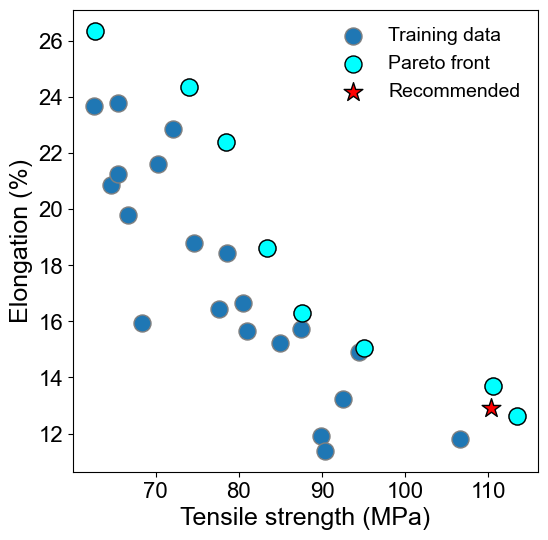

In [16]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

dataset_path = './new_datasets/first.csv'

# UCB+HV selection
#################################################

import Bgolearn.BGOsampling as BGOS

df = pd.read_csv(dataset_path)
# Visual_samples dataset
vs = pd.read_csv('../../SAC105_Data/Visual_samples.csv')
Bgolearn = BGOS.Bgolearn() 
Mymodel_1 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-2], virtual_samples = vs,min_search=False)
score_1, _= Mymodel_1.UCB()  
Mymodel_2 = Bgolearn.fit(data_matrix = df.iloc[:,:-2], Measured_response = df.iloc[:,-1], virtual_samples = vs,min_search=False)
score_2, _= Mymodel_2.UCB()


names = ['Tensile strength MPa', 'Elongation %']
Model = ToolKit.MultiOpt(vs,[score_1,score_2],names)
VS_recommended, best_idx, HV_improve = Model.HVSearch(y = df.iloc[:,-2:])


print('the recommended data is :',VS_recommended)
print('the HV is :', HV_improve[best_idx])
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_2.png', dpi=800)
plt.savefig('ParetoF_2.svg', dpi=800)
plt.show()
#################################################

## the end